In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from queue import PriorityQueue

from variable_print import p,ps,pst
from gridworld import GridworldEnv

#import temporal_difference as td

from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(0)

## `GridWorld` 초기화하기

`GridworldEnv`생성

In [4]:
nx, ny = 4, 4
env = GridworldEnv([ny, nx])

## Temporal-difference Agent Class

In [6]:
class TDAgent:
    def __init__(self,
                 gamma: float,
                 num_states: int,
                 num_actions: int,
                 epsilon: float,
                 lr: float,
                 n_step: int):

        self.gamma = gamma
        self.num_states = num_states
        self.num_actions = num_actions
        self.lr = lr
        self.epsilon = epsilon
        self.n_step = n_step

        # Initialize state value function V and action value function Q
        self.v = None
        self.q = None
        self.reset_values()

        # Initialize "policy Q"
        # "policy Q" is the one used for policy generation.
        self._policy_q = None
        self.reset_policy()

    def reset_values(self):
        self.v = np.zeros(shape=self.num_states)
        self.q = np.zeros(shape=(self.num_states, self.num_actions))

    def reset_policy(self):
        self._policy_q = np.zeros(shape=(self.num_states, self.num_actions))

    def get_action(self, state):
        prob = np.random.uniform(0.0, 1.0, 1)
        # e-greedy policy over Q
        if prob <= self.epsilon:  # random
            action = np.random.choice(range(self.num_actions))
        else:  # greedy
            action = self._policy_q[state, :].argmax()
        return action

    def update(self, episode): # n-step TD
        states, actions, rewards = episode
        ep_len = len(states)

        states += [0] * (self.n_step + 1)  # append dummy states
        rewards += [0] * (self.n_step + 1)  # append dummy rewards
        dones = [0] * ep_len + [1] * (self.n_step + 1)  #dummys <-done
        # kernel [gamma, gamma^2,... ]
        kernel = np.array([self.gamma ** i for i in range(self.n_step)])
        for i in range(ep_len):
            s = states[i]                # 현재 s
            ns = states[i + self.n_step] # 마지막 s
            done = dones[i]              # dummy는 1

            # compute n-step TD target
            g = np.sum(rewards[i:i + self.n_step] * kernel)
            # 마지막 term : done이 아니면 v[ns]를 사용
            g += (self.gamma ** self.n_step) * self.v[ns] * (1 - done)
            # v(s) <- lr * (g - v(s))
            self.v[s] += self.lr * (g - self.v[s])

    def sample_update(self, state, action, reward, next_state, done):
        # 1-step TD target
        td_target = reward + self.gamma * self.v[next_state] * (1 - done)
        self.v[state] += self.lr * (td_target - self.v[state])

    def decaying_epsilon(self, factor):
        self.epsilon *= factor

In [7]:
td_agent = TDAgent(gamma=1.0,
                      num_states=nx * ny,
                      num_actions=4,
                      epsilon=1.0,
                      lr=1e-2,
                      n_step=1)

## 1-step TD; TD(0)

1-step TD , TD(0) :

$$V(s) \leftarrow V(s) + \alpha (G_t - V(s))$$  
$$G_t = R_{t+1} + \gamma V(s_{t+1}) $$  

**1-step TD를 적용하여 episode를 시행하면서 v(s)를 update하는 함수를 만들어 보자**
>Episode는 Terminal을 만날때 까지 진행  


In [8]:
## agent.update를 사용하지 않고 직접 agent.v[s] update 함 ##
def run_episode(env, agent):
    env.reset()
    while True:
        state = env.observe()
        action = agent.get_action(state)
        next_state, reward, done, info = env.step(action)
        # 1-step TD target
        td_target = reward + agent.gamma * agent.v[next_state] * (1 - done)
        # v(s) update
        agent.v[state] += agent.lr * (td_target - agent.v[state])
        if done:  break

### episode 2000번 시행 결과 확인

In [9]:
def run_episodes(env, agent, total_eps, log_every):
    values = []
    log_iters = []
    for i in range(total_eps+1):
        run_episode(env, agent)
        if i % log_every == 0:
            values.append(agent.v.copy()) # [(16,),...]
            log_iters.append(i)
    info = dict()
    info['values'] = values
    info['iters'] = log_iters
    return info

In [10]:
%%time
total_eps = 2000
log_every = 500

td_agent.reset_values() # v,q <- 0
info = run_episodes(env, td_agent, total_eps, log_every)

CPU times: user 1.77 s, sys: 10.4 ms, total: 1.78 s
Wall time: 1.79 s


In [11]:
log_iters = info['iters']
mc_values = info['values'] # [(16,),...]

In [12]:
ps(np.array(mc_values))

<<>> Shape(5, 16)


**DP policy evaluation과 비교하기**  

In [13]:
from tensorized_dp import TensorDP

dp_agent = TensorDP()
dp_agent.set_env(env)
v_pi = dp_agent.policy_evaluation()

Environment : #state = 16 , #actions = 4 


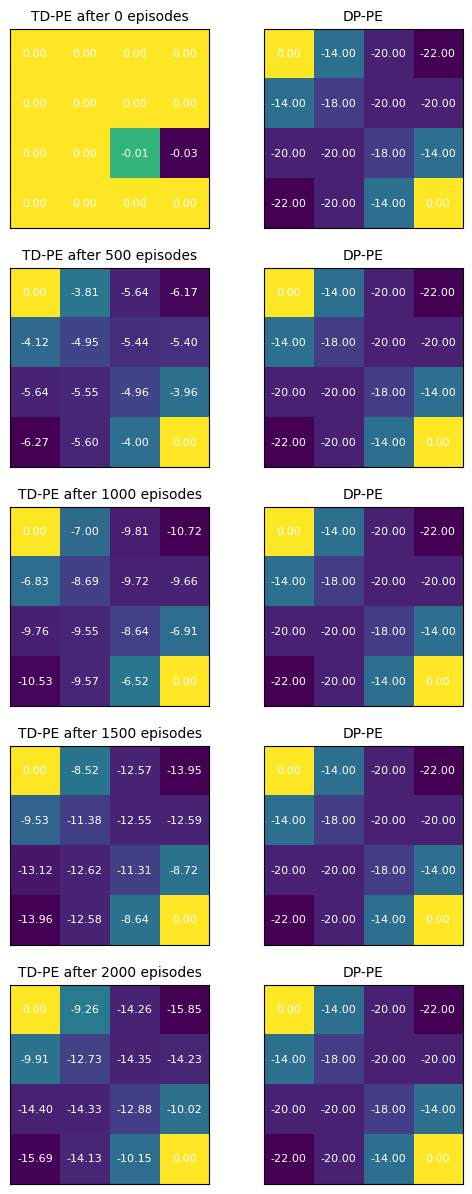

In [14]:
n_rows = len(log_iters)
figsize_multiplier = 3

fig, ax = plt.subplots(n_rows, 2, figsize=(2*figsize_multiplier,
                                           n_rows*figsize_multiplier))

for viz_i, i in enumerate(log_iters):
    visualize_value_function(ax[viz_i, 0], mc_values[viz_i], nx, ny,
                            plot_cbar=False)
    _ = ax[viz_i, 0].set_title("TD-PE after {} episodes".format(i), size=10)

    visualize_value_function(ax[viz_i, 1], v_pi, nx, ny,
                             plot_cbar=False)
    _ = ax[viz_i, 1].set_title("DP-PE", size=10)

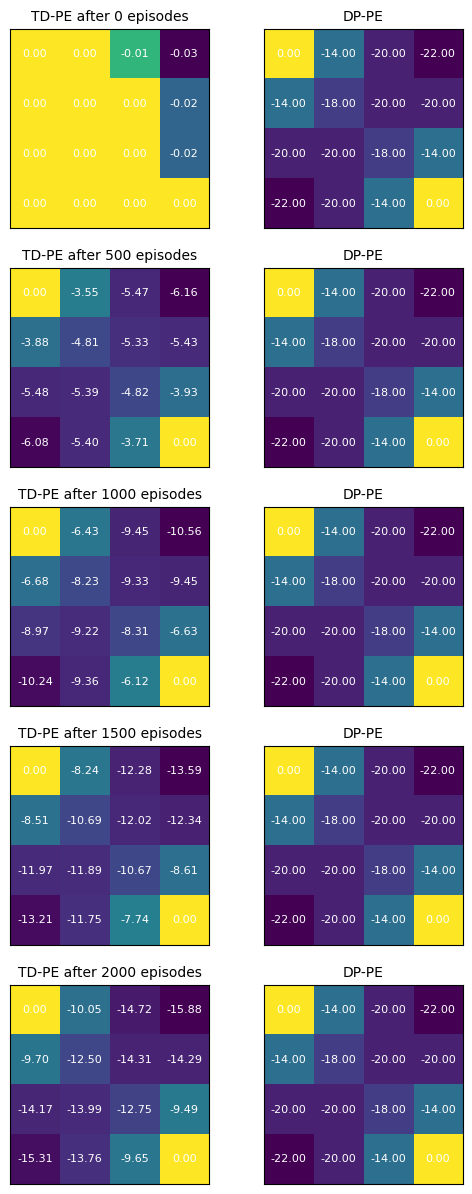

###  TD evaluation 결과의 분산 확인해 보기  
>10번을 시행하여 episode 진행에 따른 error의 평균, 분산 변화를 확인

In [15]:
%%time
reps = 10
values_over_runs = []
total_eps = 3000
log_every = 30

for i in range(reps):
    td_agent.reset_values()
    print(f"start to run {i}th experiment ... ")
    info = run_episodes(env, td_agent, total_eps, log_every)
    values_over_runs.append(info['values'])

values_over_runs = np.stack(values_over_runs)

start to run 0th experiment ... 
start to run 1th experiment ... 
start to run 2th experiment ... 
start to run 3th experiment ... 
start to run 4th experiment ... 
start to run 5th experiment ... 
start to run 6th experiment ... 
start to run 7th experiment ... 
start to run 8th experiment ... 
start to run 9th experiment ... 
CPU times: user 25.4 s, sys: 111 ms, total: 25.5 s
Wall time: 26.3 s


Wall time: 28 s


In [16]:
v_pi_expanded = np.expand_dims(v_pi, axis=(0,1)) # v_pi: from DP

In [17]:
errors = np.linalg.norm(values_over_runs - v_pi_expanded, axis=-1)
error_mean = np.mean(errors, axis=0)
error_std = np.std(errors, axis=0)

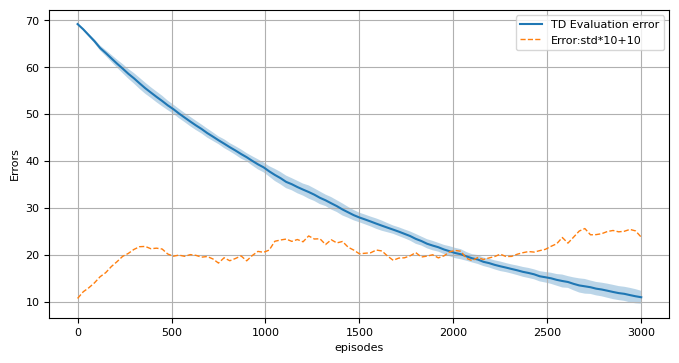

In [18]:
fig, ax = plt.subplots(1,1,figsize=(8,4))
ax.grid()
ax.fill_between(x=info['iters'],
                y1=error_mean + error_std,
                y2=error_mean - error_std,
                alpha=0.3)

ax.plot(info['iters'], error_mean, '-',label='TD Evaluation error')
ax.plot(info['iters'], error_std*10+10,'--',label="Error:std*10+10",linewidth=1)
ax.legend()
_ = ax.set_xlabel('episodes')
_ = ax.set_ylabel('Errors')

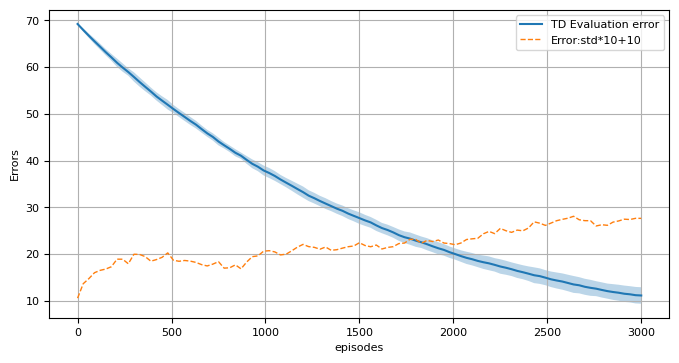

### Monte-carlo method와 분산 비교
MC : TD에 비해 분산이 크고 bias는 적은지 확인

In [19]:
g_drive = path + "datasets/DRL/"; os.makedirs(g_drive, exist_ok=True)
mc_errors = np.load(g_drive+'mc_errors.npy')
mc_error_mean = np.mean(mc_errors, axis=0)
mc_error_std = np.std(mc_errors, axis=0)

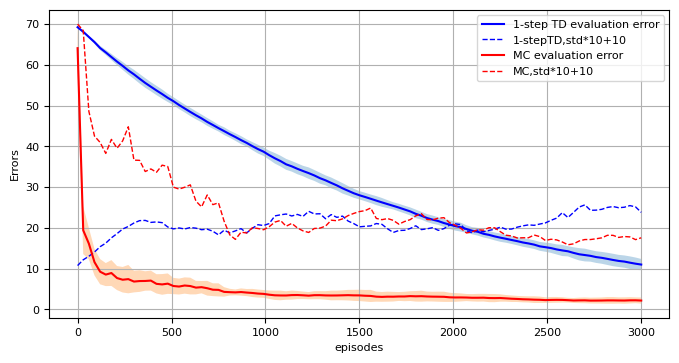

In [20]:
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.grid()
ax.fill_between(x=info['iters'],
                y1=error_mean + error_std,
                y2=error_mean - error_std,
                alpha=0.3)
ax.plot(info['iters'], error_mean, 'b-', label='1-step TD evaluation error')
ax.plot(info['iters'], error_std*10+10,'b--', label="1-stepTD,std*10+10",linewidth=1)

ax.fill_between(x=info['iters'],
                y1=mc_error_mean + mc_error_std,
                y2=mc_error_mean - mc_error_std,
                alpha=0.3)
ax.plot(info['iters'], mc_error_mean, 'r-', label='MC evaluation error')
ax.plot(info['iters'], mc_error_std*10+10,'r--',label="MC,std*10+10",linewidth=1)

ax.legend()
_ = ax.set_xlabel('episodes')
_ = ax.set_ylabel('Errors')

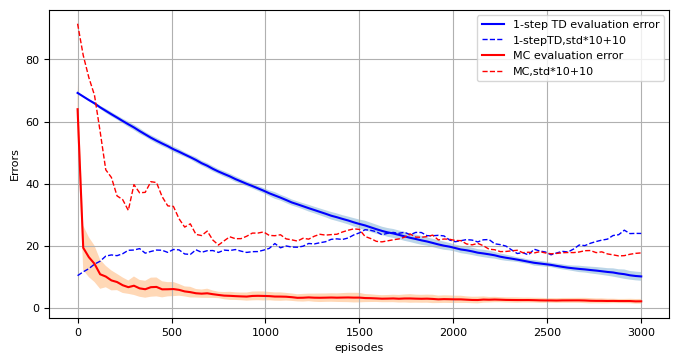

## n-step TD 성능 확인



*Agent 생성

In [21]:
n_steps = 5
n_step_td_agent = TDAgent(gamma=1.0,
                             num_states=nx * ny,
                             num_actions=4,
                             epsilon=1.0,
                             lr=1e-2,
                             n_step=n_steps)

### n-step TD의 target

n-step TD 는 직후 보상뿐만 아니라 n-step 뒤의 보상까지 return 추산에 사용  
$$ G_t^{n} = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots + \gamma^{n-1} R_{t+n} + \gamma^n V(S_{t+n}) $$

>n-step TD를 구현할 때는 각 에피소드의 길이가 random variable 이기 때문에  
>episode의 한 형태로 구현 하게 됨


In [23]:
def run_episode(env, agent):
    env.reset()
    states = []
    actions = []
    rewards = []
    while True :# for i in range(10000):
        state = env.observe()
        action = agent.get_action(state)
        next_state, reward, done, info = env.step(action)

        states.append(state)
        actions.append(action)
        rewards.append(reward)

        if done:
            break
    episode = (states, actions, rewards)
    agent.update(episode)

### agent.update() method  
추가 사항 : episode의 끝에서 `n-step` 보다 짧게 남은 state 들에 대한 리턴 처리  

> 에피소드의 길이가 10 이고, `n-step` 이 2일때  
> 9번째 상태 $S_9$ 에 해당하는 TD target은  
> $$ G_9 = R_{10} + \gamma R_{11} + \gamma^2 V(S_{11}) $$
> 에서 $R_{11}$, $S_{11}$ 은 없음  

1-step TD 에서  
```python
    td_target = reward + self.gamma * self.v[next_state] * (1 - done)
```
로 마지막 상태를 계산에서 제외 하였음

**Teminal state**
>agent가 종결상태에 방문하게 되면 어느 행동을 하든 종결상태로 __되 돌아옴__  
>그에 따른 __보상은 0__으로 볼 수 있음  

>부족한 state를 dummy state(state, reword, done)를 넣어서 처리 하면 됨  


```python
def update(self, episode):
    states, actions, rewards = episode
    ep_len = len(states)

    states += [0] * (self.n_step + 1)  # append dummy states(0)
    rewards += [0] * (self.n_step + 1)  # append dummy rewards(0)
    dones = [0] * ep_len + [1] * (self.n_step + 1)  #dummys <-done(1)
    # kernel [1, gamma, gamma^2,... ]
    kernel = np.array([self.gamma ** i for i in range(self.n_step)])
    for i in range(ep_len):
        s = states[i]                # 현재 s    
        ns = states[i + self.n_step] # 마지막 s
        done = dones[i]              # dummy는 1

        # compute n-step TD target
        g = np.sum(rewards[i:i + self.n_step] * kernel)
        # 마지막 term :  + r*v(s)
        g += (self.gamma ** self.n_step) * self.v[ns] * (1 - done)
        # v(s) <- lr * (g - v(s))
        self.v[s] += self.lr * (g - self.v[s])
```

In [24]:
%%time
n_step_td_agent.reset_values()
info = run_episodes(env, n_step_td_agent, 2000, 500)

CPU times: user 1.64 s, sys: 14.4 ms, total: 1.66 s
Wall time: 1.65 s


In [25]:
log_iters = info['iters']
mc_values = info['values']

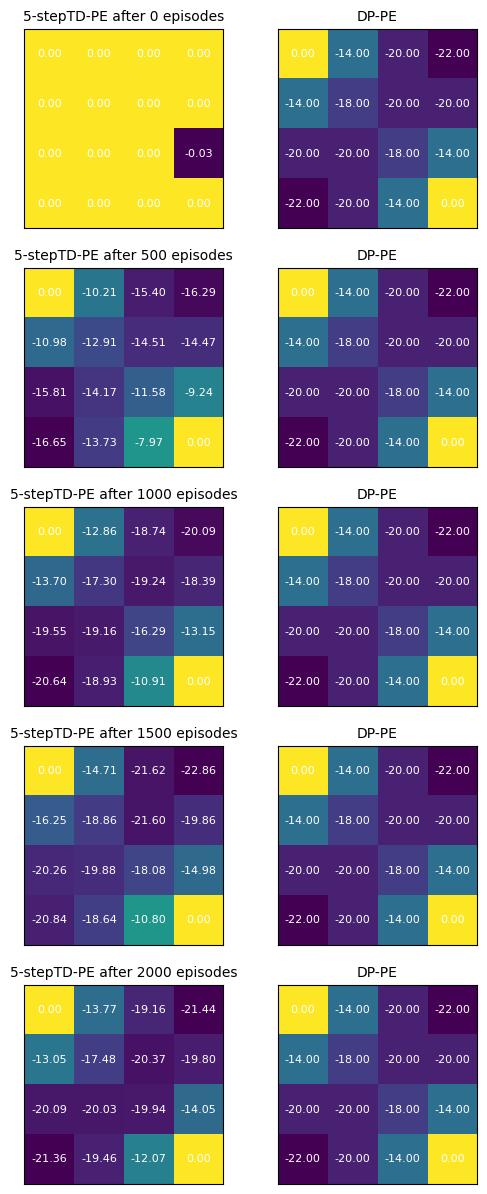

In [26]:
n_rows = len(log_iters)
figsize_multiplier = 3

fig, ax = plt.subplots(n_rows, 2, figsize=(2*figsize_multiplier,
                                           n_rows*figsize_multiplier))

for viz_i, i in enumerate(log_iters):
    visualize_value_function(ax[viz_i, 0], mc_values[viz_i], nx, ny,
                            plot_cbar=False)
    _ = ax[viz_i, 0].set_title("5-stepTD-PE after {} episodes".format(i), size=10)

    visualize_value_function(ax[viz_i, 1], v_pi, nx, ny,
                             plot_cbar=False)
    _ = ax[viz_i, 1].set_title("DP-PE", size=10)

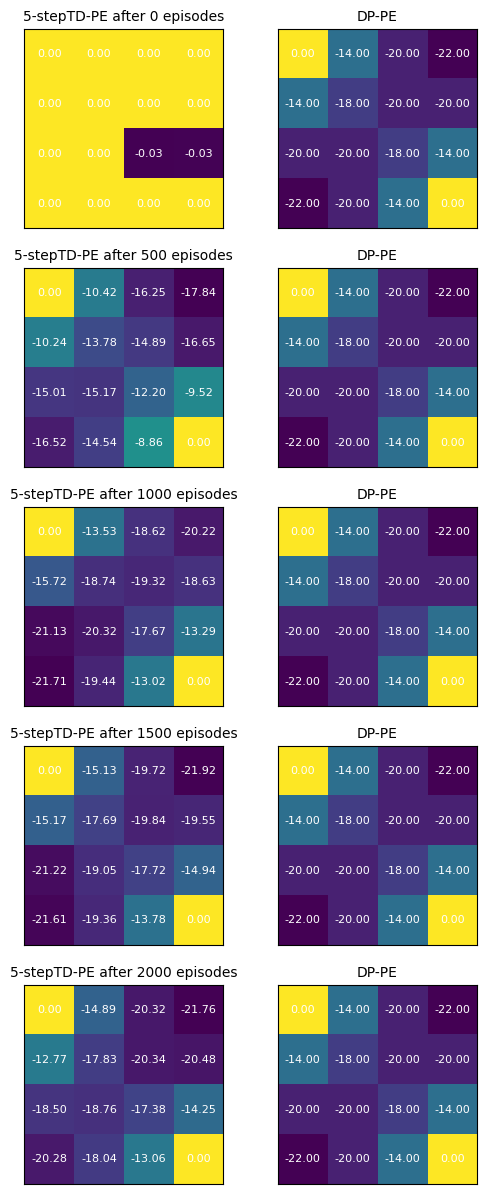

### n-step TD와 1-step TD 비교하기

In [27]:
%%time
reps = 10
values_over_runs = []
total_eps = 3000
log_every = 30

for i in range(reps):
    n_step_td_agent.reset_values()
    print("start to run {} th experiment ... ".format(i))
    info = run_episodes(env, n_step_td_agent, total_eps, log_every)
    values_over_runs.append(info['values'])

n_step_values_over_runs = np.stack(values_over_runs)

start to run 0 th experiment ... 
start to run 1 th experiment ... 
start to run 2 th experiment ... 
start to run 3 th experiment ... 
start to run 4 th experiment ... 
start to run 5 th experiment ... 
start to run 6 th experiment ... 
start to run 7 th experiment ... 
start to run 8 th experiment ... 
start to run 9 th experiment ... 
CPU times: user 26.5 s, sys: 130 ms, total: 26.6 s
Wall time: 26.9 s


Wall time: 29.9 s

In [28]:
n_step_errors = np.linalg.norm(n_step_values_over_runs - v_pi_expanded, axis=-1)
n_step_error_mean = np.mean(n_step_errors, axis=0)
n_step_error_std = np.std(n_step_errors, axis=0)

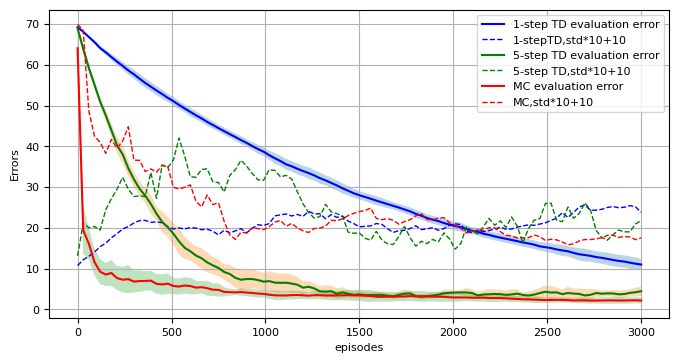

In [29]:
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.grid()
ax.fill_between(x=info['iters'],
                y1=error_mean + error_std,
                y2=error_mean - error_std,
                alpha=0.3)
ax.plot(info['iters'], error_mean, 'b-', label='1-step TD evaluation error')
ax.plot(info['iters'], error_std*10+10,'b--', label="1-stepTD,std*10+10",linewidth=1)

ax.fill_between(x=info['iters'],
                y1=n_step_error_mean + n_step_error_std,
                y2=n_step_error_mean - n_step_error_std,
                alpha=0.3)
ax.plot(info['iters'], n_step_error_mean,'g-', label=f"{n_steps}-step TD evaluation error")
ax.plot(info['iters'], n_step_error_std*10+10,'g--', label=f"{n_steps}-step TD,std*10+10",linewidth=1)

ax.fill_between(x=info['iters'],
                y1=mc_error_mean + mc_error_std,
                y2=mc_error_mean - mc_error_std,
                alpha=0.3)
ax.plot(info['iters'], mc_error_mean,'r-', label='MC evaluation error')
ax.plot(info['iters'], mc_error_std*10+10,'r--',label="MC,std*10+10",linewidth=1)

ax.legend()
_ = ax.set_xlabel('episodes')
_ = ax.set_ylabel('Errors')

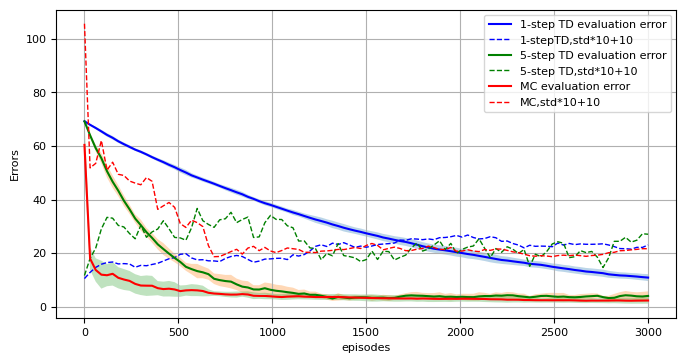